In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
import statsmodels.api as sms


In [1]:
#For importing the Excel file
from google.colab import files
uploaded = files.upload()



Saving Response Sheet (4) (1).xlsx to Response Sheet (4) (1).xlsx


In [4]:
print("Please upload the file or dataset (.csv or .xlsx)")
data =  pd.read_excel('/content/Response Sheet (4) (1).xlsx')
data.head()
data = list(uploaded.keys())[0]

#autodetecting:
if data.endswith('.csv'):
  df = pd.read_csv(data)
else:
  df = pd.read_excel(data)

print(f"File '{data}' Successfully uploaded")

Please upload the file or dataset (.csv or .xlsx)
File 'Response Sheet (4) (1).xlsx' Successfully uploaded


In [5]:
#data cleaning process

column_map = {
    '1. Self-reported GPA/ average grade(number)': 'gpa',
    '4. Sleep quality': 'raw_comp1_quality',
    'Sleep Latency (mins)2': 'raw_comp2_latency',
    'Sleep Duration': 'raw_comp3_duration',
    'Estimated average bedtime2': 'raw_bedtime',
    'Wake-up time': 'raw_wakeup',
    'Sleep disturbances': 'raw_comp5_disturbances',
    'Use of sleep medication': 'raw_comp6_medication',
    'Daytime dysfunction': 'raw_comp7_dysfunction_sum',
    'Estimated avg study hrs': 'study_hours',
    '3. Stress level': 'stress_level',
    'Estimated screentime': 'screen_time',
    '2. Gender': 'gender',
    '3. Year of Study': 'year_of_study'
}

df_clean = df[column_map.keys()].rename(columns=column_map).copy()

numeric_cols = [
    'gpa','raw_comp1_quality','raw_comp2_latency','raw_comp3_duration',
    'raw_bedtime','raw_wakeup','raw_comp5_disturbances','raw_comp6_medication',
    'raw_comp7_dysfunction_sum','study_hours','stress_level','screen_time'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna(subset=['gpa','raw_comp1_quality','raw_comp2_latency',
                                   'raw_comp3_duration','raw_bedtime','raw_wakeup'])

print("Data cleaned and essential columns")
df_clean.head()

Data cleaned and essential columns


,gpa,raw_comp1_quality,raw_comp2_latency,raw_comp3_duration,raw_bedtime,raw_wakeup,raw_comp5_disturbances,raw_comp6_medication,raw_comp7_dysfunction_sum,study_hours,stress_level,screen_time,gender,year_of_study
0,6.00,3.0,10.0,9.0,11.0,8.0,2.0,0.0,1.0,1.0,5.0,3.0,Female,3rd Year
1,8.00,2.0,15.0,5.3,1.0,6.3,3.0,0.0,3.0,2.0,2.0,4.0,Female,3rd Year
2,5.00,3.0,2.0,7.3,11.0,6.3,2.0,0.0,2.0,1.0,2.0,1.5,Female,3rd Year
3,9.54,4.0,7.0,6.0,11.0,5.0,2.0,0.0,0.0,3.0,2.0,1.0,Male,3rd Year
4,5.63,1.0,9.0,8.3,11.0,7.3,2.0,0.0,4.0,1.0,4.0,1.5,Female,3rd Year


In [6]:
#PSQI calculation

# Comp1: Subjective Sleep Quality
df_clean['comp1_score'] = df_clean['raw_comp1_quality'].map({1:0, 2:1, 3:2, 4:3, 5:3})

# Comp 2: Sleep Latency
df_clean['comp2_score'] = pd.cut(
    df_clean['raw_comp2_latency'],
    bins=[-1,15,30,60,10000],
    labels=[0,1,2,3]
).astype(int)

# Comp 3: Sleep Duration
df_clean['comp3_score'] = np.select(
    [
        df_clean['raw_comp3_duration'] > 7,
        (df_clean['raw_comp3_duration'] > 6) & (df_clean['raw_comp3_duration'] <= 7),
        (df_clean['raw_comp3_duration'] > 5) & (df_clean['raw_comp3_duration'] <= 6),
        df_clean['raw_comp3_duration'] <= 5
    ],
    [0,1,2,3],
    default=0
)

# Comp 4: Sleep Efficiency
df_clean['time_in_bed'] = np.where(
    df_clean['raw_wakeup'] < df_clean['raw_bedtime'],
    (12 - df_clean['raw_bedtime']) + df_clean['raw_wakeup'],
    df_clean['raw_wakeup'] - df_clean['raw_bedtime']
)

df_clean['hse_percent'] = (df_clean['raw_comp3_duration'] / df_clean['time_in_bed']) * 100
df_clean['comp4_score'] = pd.cut(
    df_clean['hse_percent'], bins=[-1,65,75,85,150], labels=[3,2,1,0]
).astype(int)

# Comp 5 and 6 implemented directly
df_clean['comp5_score'] = df_clean['raw_comp5_disturbances']
df_clean['comp6_score'] = df_clean['raw_comp6_medication']

# Comp 7: Daytime Dysfunction - which is a sum of motivation and daytime naps
df_clean['comp7_score'] = df_clean['raw_comp7_dysfunction_sum'].map(
    {0:0,1:1,2:1,3:2,4:2,5:3,6:3}
).fillna(3)

print("PSQI components scored")


PSQI components scored


In [7]:
#Calculating the global PSQI score
component_cols = [
    'comp1_score','comp2_score','comp3_score','comp4_score',
    'comp5_score','comp6_score','comp7_score'
]

df_clean['Global_PSQI_Score'] = df_clean[component_cols].sum(axis=1)

print("Global PSQI Score calculated (0–21)")

Global PSQI Score calculated (0–21)


In [8]:
#descriptive statistics
print(df_clean[['gpa','Global_PSQI_Score','study_hours','stress_level']].describe())

df_clean['poor_sleep'] = df_clean['Global_PSQI_Score'] > 5
prevalence = df_clean['poor_sleep'].mean() * 100
print(f"Poor Sleep Prevalence: {prevalence:.2f}%")

             gpa  Global_PSQI_Score  study_hours  stress_level
count  59.000000          59.000000    59.000000     59.000000
mean    7.386102           5.508475     1.855932      3.152542
std     1.323586           1.264541     1.000219      1.171700
min     4.500000           3.000000     1.000000      1.000000
25%     6.210000           5.000000     1.000000      2.000000
50%     7.500000           6.000000     2.000000      3.000000
75%     8.515000           6.000000     2.000000      4.000000
max     9.540000           8.000000     5.000000      5.000000
Poor Sleep Prevalence: 50.85%


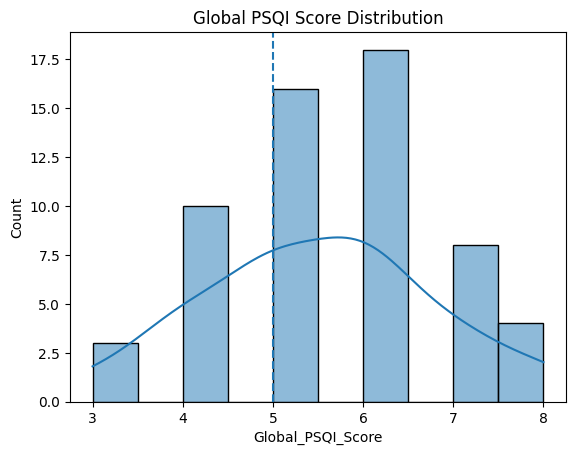

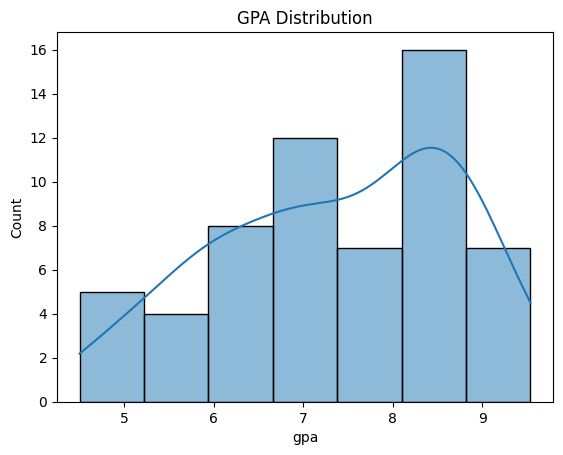

In [9]:
#Plots on Global PSQI score distribution
#hitogram
sns.histplot(df_clean['Global_PSQI_Score'], kde=True)
plt.axvline(5, linestyle='--')
plt.title("Global PSQI Score Distribution")
plt.show()

sns.histplot(df_clean['gpa'], kde=True)
plt.title("GPA Distribution")
plt.show()

In [10]:
# correlation on (sleep VS gpa)
#bivariate analysis
#carlpearson correlation

analysis_df = df_clean[['gpa','Global_PSQI_Score','study_hours','stress_level','screen_time']].dropna()

r, p = sts.pearsonr(analysis_df['Global_PSQI_Score'], analysis_df['gpa'])
print(f"Correlation (r) = {r:.3f}, p = {p:.3f}")

Correlation (r) = 0.118, p = 0.373


In [11]:
#performing multiple regressions
#multivariate analysis
Y = analysis_df['gpa']
X = sms.add_constant(analysis_df[['Global_PSQI_Score','study_hours','stress_level','screen_time']])

model = sms.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    gpa   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     23.20
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.40e-11
Time:                        16:49:14   Log-Likelihood:                -70.254
No. Observations:                  59   AIC:                             150.5
Df Residuals:                      54   BIC:                             160.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.8380      0.73

In [12]:
#for saving the cleaned data
df_clean.to_excel("Final_PSQI_Cleaned_Data.xlsx", index=False)
print(" Cleaned dataset saved as: Final_PSQI_Cleaned_Data.xlsx")


 Cleaned dataset saved as: Final_PSQI_Cleaned_Data.xlsx
